In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ts-forecasting/train.parquet
/kaggle/input/competitions/ts-forecasting/test.parquet


In [2]:
# ============================================
# SECTION 0: CONFIG / SETUP
# ============================================

import sys
import os
import time
import datetime
import warnings
import numpy as np
import pandas as pd
import polars as pl
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import shap
from tqdm import tqdm
from pathlib import Path

warnings.filterwarnings('ignore')

# Timer start
notebook_start_time = time.time()
print(f"⏱️ Notebook started at: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# ============================================
# STUDENT INFO (Kaggle template requirement)
# ============================================
STUDENT_NAME = "tomasz"
SCORE = 0.1140  # public leaderboard score
EMAIL = "tomekiel@vp.pl"

print(f"Student: {STUDENT_NAME}, Score: {SCORE}, Email: {EMAIL}")

# ============================================
# CONFIGURATION
# ============================================

# Walk-forward settings (for later use)
WINDOW_SIZE = 500
STEP = 100
MIN_TS = 1
MAX_TS_TRAIN = 3601

# For baseline and SHAP (simpler)
SEEDS = [42]
HORIZONS = [1, 3, 10, 25]

# For walk-forward validation (3 folds – to be used in section 6)
WF_FOLDS = [
    {'train_end': 2000, 'valid_start': 2000, 'valid_end': 2500},
    {'train_end': 2500, 'valid_start': 2500, 'valid_end': 3000},
    {'train_end': 3000, 'valid_start': 3000, 'valid_end': 3600}
]

print("="*60)
print("CONFIGURATION")
print("="*60)
print(f"Seeds: {SEEDS}")
print(f"Horizons: {HORIZONS}")
print(f"Walk-forward folds: {WF_FOLDS}")
print(f"Window size: {WINDOW_SIZE}, Step: {STEP}")
print("="*60)

# ============================================
# GPU SETTINGS (commented – optional)
# ============================================
# For LightGBM: add 'device': 'gpu' to params
# For XGBoost: add 'tree_method': 'hist', 'device': 'cuda'
# For CatBoost: add 'task_type': 'GPU'

# ============================================
# VERSION CHECK (Kaggle requirement)
# ============================================
print("\n" + "="*60)
print("ENVIRONMENT VERSIONS")
print("="*60)
print(f"Python version: {sys.version}")
print(f"LightGBM version: {lgb.__version__}")
print(f"XGBoost version: {xgb.__version__}")
#print(f"CatBoost version: {CatBoostRegressor.__version__}")
print(f"Polars version: {pl.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"SHAP version: {shap.__version__}")
print("="*60)

# Polars config
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(100)

⏱️ Notebook started at: 2026-04-16 12:56:46
Student: tomasz, Score: 0.114, Email: tomekiel@vp.pl
CONFIGURATION
Seeds: [42]
Horizons: [1, 3, 10, 25]
Walk-forward folds: [{'train_end': 2000, 'valid_start': 2000, 'valid_end': 2500}, {'train_end': 2500, 'valid_start': 2500, 'valid_end': 3000}, {'train_end': 3000, 'valid_start': 3000, 'valid_end': 3600}]
Window size: 500, Step: 100

ENVIRONMENT VERSIONS
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
LightGBM version: 4.6.0
XGBoost version: 3.2.0
Polars version: 1.35.2
NumPy version: 2.0.2
SHAP version: 0.50.0


polars.config.Config

In [3]:
# ============================================
# SECTION 1: DATA LOADING + CLEANING
# ============================================

print("\n" + "="*60)
print("DATA LOADING")
print("="*60)

# ============================================
# 3 OPTIONS FOR DATA LOADING
# ============================================

# Option A: Kaggle environment
KAGGLE_ENV = os.path.exists('/kaggle/input')

# Option B: Local path (your computer)
LOCAL_TRAIN_PATH = Path("../data/train.parquet")
LOCAL_TEST_PATH = Path("../data/test.parquet")

# Option C: Internet download (for teacher)
# Placeholder – replace with actual download links
DOWNLOAD_TRAIN_URL = "LINK_DO_TRAIN"  # e.g. "https://drive.google.com/uc?export=download&id=XXX"
DOWNLOAD_TEST_URL = "LINK_DO_TEST"
DOWNLOAD_DIR = Path("../downloaded_data")

def download_from_url(url, destination):
    """Download file from URL using wget or requests"""
    import requests
    response = requests.get(url, stream=True)
    with open(destination, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

# Select loading method
if KAGGLE_ENV:
    print("🐧 Loading data from Kaggle environment...")
    train_path = '/kaggle/input/competitions/ts-forecasting/train.parquet'
    test_path = '/kaggle/input/competitions/ts-forecasting/test.parquet'
    train_full = pl.read_parquet(train_path)
    test_full = pl.read_parquet(test_path)
    
elif LOCAL_TRAIN_PATH.exists() and LOCAL_TEST_PATH.exists():
    print("💻 Loading data from local path...")
    train_full = pl.read_parquet(LOCAL_TRAIN_PATH)
    test_full = pl.read_parquet(LOCAL_TEST_PATH)
    
else:
    print("🌐 Downloading data from internet...")
    DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
    download_from_url(DOWNLOAD_TRAIN_URL, DOWNLOAD_DIR / "train.parquet")
    download_from_url(DOWNLOAD_TEST_URL, DOWNLOAD_DIR / "test.parquet")
    train_full = pl.read_parquet(DOWNLOAD_DIR / "train.parquet")
    test_full = pl.read_parquet(DOWNLOAD_DIR / "test.parquet")

print(f"✅ Train: {train_full.shape}")
print(f"✅ Test: {test_full.shape}")

# ============================================
# TYPE CONVERSION
# ============================================
print("\n🔄 Type conversion...")

categorical_cols = ['code', 'sub_code', 'sub_category']
for col in categorical_cols:
    if col in train_full.columns:
        train_full = train_full.with_columns(pl.col(col).cast(pl.Categorical))
    if col in test_full.columns:
        test_full = test_full.with_columns(pl.col(col).cast(pl.Categorical))

int_cols = ['horizon', 'ts_index']
for col in int_cols:
    if col in train_full.columns:
        train_full = train_full.with_columns(pl.col(col).cast(pl.Int16))
    if col in test_full.columns:
        test_full = test_full.with_columns(pl.col(col).cast(pl.Int16))

feature_cols = [c for c in train_full.columns if c.startswith('feature_')]
for col in feature_cols:
    if col in train_full.columns and train_full[col].dtype == pl.Float64:
        train_full = train_full.with_columns(pl.col(col).cast(pl.Float32))
    if col in test_full.columns and test_full[col].dtype == pl.Float64:
        test_full = test_full.with_columns(pl.col(col).cast(pl.Float32))

print(f"✅ Type converted. Features: {len(feature_cols)}")

# ============================================
# SANITY CHECK (no leakage, same columns)
# ============================================
print("\n🔍 Sanity check...")

# Check if test has same feature columns as train (without y_target)
test_feature_cols = [c for c in test_full.columns if c.startswith('feature_')]
assert len(test_feature_cols) == len(feature_cols), "Test missing features!"

# Check ts_index order (minimal)
print(f"   Train ts_index range: {train_full['ts_index'].min()} - {train_full['ts_index'].max()}")
print(f"   Test ts_index range: {test_full['ts_index'].min()} - {test_full['ts_index'].max()}")

# No future data in train
assert train_full['ts_index'].max() <= 3601, "Train contains ts_index > 3601!"

print("✅ Sanity check passed")

# ============================================
# CAUSAL IMPUTATION (EWMA + forward + 0)
# ============================================
print("\n📌 CAUSAL IMPUTATION (without cross-horizon)")

group_keys = ['code', 'sub_code', 'sub_category', 'horizon']

print(f"Processing {len(feature_cols)} features...")

for c in feature_cols:
    if train_full[c].null_count() > 0 or (c in test_full.columns and test_full[c].null_count() > 0):
        train_full = train_full.with_columns(
            pl.when(pl.col(c).is_null())
            .then(
                pl.coalesce([
                    pl.col(c).ewm_mean(span=20, adjust=False).over(group_keys),
                    pl.col(c).forward_fill().over(group_keys),
                    pl.col(c).ewm_mean(span=10, adjust=False).over(group_keys),
                    pl.lit(0.0)
                ])
            )
            .otherwise(pl.col(c))
            .alias(c)
        )
        
        if c in test_full.columns:
            test_full = test_full.with_columns(
                pl.when(pl.col(c).is_null())
                .then(
                    pl.coalesce([
                        pl.col(c).ewm_mean(span=20, adjust=False).over(group_keys),
                        pl.col(c).forward_fill().over(group_keys),
                        pl.col(c).ewm_mean(span=10, adjust=False).over(group_keys),
                        pl.lit(0.0)
                    ])
                )
                .otherwise(pl.col(c))
                .alias(c)
            )

# Final fallback to 0
for c in feature_cols:
    if train_full[c].null_count() > 0:
        train_full = train_full.with_columns(pl.col(c).fill_null(0).alias(c))
    if c in test_full.columns and test_full[c].null_count() > 0:
        test_full = test_full.with_columns(pl.col(c).fill_null(0).alias(c))

print("✅ Imputation done. NaNs: 0")

# Optional: keep a clean copy (though after imputation it's already clean)
train_clean = train_full.clone()
test_clean = test_full.clone()

print("✅ Data loading and cleaning complete")


DATA LOADING
🐧 Loading data from Kaggle environment...
✅ Train: (5337414, 94)
✅ Test: (1447107, 92)

🔄 Type conversion...
✅ Type converted. Features: 86

🔍 Sanity check...
   Train ts_index range: 1 - 3601
   Test ts_index range: 3602 - 4376
✅ Sanity check passed

📌 CAUSAL IMPUTATION (without cross-horizon)
Processing 86 features...
✅ Imputation done. NaNs: 0
✅ Data loading and cleaning complete


In [4]:
# ============================================
# SECTION 2: BASELINE LGBM (no lags, no time features, no BNN)
# ============================================
# Cel: Punkt odniesienia – prosty model per horizon
# Walidacja czasowa: train (ts ≤ 3000), valid (3001–3600)
# Metryki: RMSE, MAE, R², Weighted RMSE, Pearson, std(y_pred) vs std(y_target)
# ============================================

print("\n" + "="*60)
print("BASELINE LGBM (NO LAGS, NO TIME FEATURES)")
print("="*60)

# ============================================
# PARAMETRY BAZOWE (proste, bez udoskonaleń)
# ============================================
def get_baseline_params(horizon: int, seed: int = 42) -> dict:
    """Proste parametry LightGBM dla wszystkich horyzontów (baseline)"""
    return {
        'objective': 'regression',
        'metric': 'rmse',
        'num_leaves': 50,
        'learning_rate': 0.05,
        'n_estimators': 300,
        'max_depth': 10,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'random_state': seed,
        'verbose': -1
    }

# ============================================
# BAZOWE CECHY (tylko feature_*, bez time_features)
# ============================================
baseline_features = [c for c in train_full.columns if c.startswith('feature_')]
print(f"Baseline features: {len(baseline_features)}")

# ============================================
# SPLIT CZASOWY (train ≤ 3000, valid 3001–3600)
# ============================================
TRAIN_SPLIT = 3000
VALID_START = 3001
VALID_END = 3600

print(f"Time split: train (ts ≤ {TRAIN_SPLIT}), valid ({VALID_START}–{VALID_END})")

# ============================================
# STORE RESULTS FOR COMPARISON
# ============================================
baseline_results = {}

# ============================================
# METRYKI (zgodne z konkursem + dodatkowe)
# ============================================
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / (ss_tot + 1e-8))

def pearson(y_true, y_pred):
    return np.corrcoef(y_true, y_pred)[0, 1]

def weighted_rmse_score(y_true, y_pred, w):
    """Kaggle competition metric (higher = better)"""
    def _clip01(x): return float(np.minimum(np.maximum(x, 0.0), 1.0))
    denom = np.sum(w * y_true ** 2)
    if denom == 0:
        return 0.0
    ratio = np.sum(w * (y_true - y_pred) ** 2) / denom
    return float(np.sqrt(1.0 - _clip01(ratio)))

# ============================================
# PĘTLA PO HORYZONTACH
# ============================================
for horizon in HORIZONS:
    print(f"\n{'='*60}")
    print(f"HORIZON: {horizon}")
    print(f"{'='*60}")
    
    # Filter data
    train_h = train_full.filter(pl.col('horizon') == horizon)
    
    # Split czasowy
    train_split = train_h.filter(pl.col('ts_index') <= TRAIN_SPLIT)
    valid_split = train_h.filter(
        (pl.col('ts_index') >= VALID_START) & (pl.col('ts_index') <= VALID_END)
    )
    
    print(f"  Train samples: {len(train_split):,} (ts ≤ {TRAIN_SPLIT})")
    print(f"  Valid samples: {len(valid_split):,} ({VALID_START}–{VALID_END})")
    
    # Prepare data
    X_train = train_split.select(baseline_features).to_numpy()
    y_train = train_split['y_target'].to_numpy().ravel()
    w_train = train_split['weight'].to_numpy().ravel()
    
    X_valid = valid_split.select(baseline_features).to_numpy()
    y_valid = valid_split['y_target'].to_numpy().ravel()
    w_valid = valid_split['weight'].to_numpy().ravel()
    
    # Train model
    params = get_baseline_params(horizon, SEEDS[0])
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_valid_pred = model.predict(X_valid)
    
    # ============================================
    # TRAIN METRICS
    # ============================================
    train_rmse = rmse(y_train, y_train_pred)
    train_mae = mae(y_train, y_train_pred)
    train_r2 = r2(y_train, y_train_pred)
    train_pearson = pearson(y_train, y_train_pred)
    train_weighted = weighted_rmse_score(y_train, y_train_pred, w_train)
    
    # ============================================
    # VALIDATION METRICS
    # ============================================
    valid_rmse = rmse(y_valid, y_valid_pred)
    valid_mae = mae(y_valid, y_valid_pred)
    valid_r2 = r2(y_valid, y_valid_pred)
    valid_pearson = pearson(y_valid, y_valid_pred)
    valid_weighted = weighted_rmse_score(y_valid, y_valid_pred, w_valid)
    
    # ============================================
    # OVERFIT CHECK (difference between train and valid)
    # ============================================
    overfit_rmse = valid_rmse - train_rmse
    overfit_pearson = train_pearson - valid_pearson
    overfit_r2 = train_r2 - valid_r2
    
    # ============================================
    # DIAGNOSTICS
    # ============================================
    print(f"\n  📊 TRAIN METRICS:")
    print(f"    RMSE: {train_rmse:.6f}")
    print(f"    MAE: {train_mae:.6f}")
    print(f"    R²: {train_r2:.6f}")
    print(f"    Pearson: {train_pearson:.6f}")
    print(f"    Weighted RMSE (Kaggle): {train_weighted:.6f}")
    print(f"    y_pred std: {y_train_pred.std():.4f} (target std: {y_train.std():.4f})")
    
    print(f"\n  📊 VALIDATION METRICS:")
    print(f"    RMSE: {valid_rmse:.6f}")
    print(f"    MAE: {valid_mae:.6f}")
    print(f"    R²: {valid_r2:.6f}")
    print(f"    Pearson: {valid_pearson:.6f}")
    print(f"    Weighted RMSE (Kaggle): {valid_weighted:.6f}")
    print(f"    y_pred std: {y_valid_pred.std():.4f} (target std: {y_valid.std():.4f})")
    
    print(f"\n  📊 OVERFIT CHECK (train - valid):")
    print(f"    RMSE difference: {overfit_rmse:.6f} {'⚠️ OVERFIT' if overfit_rmse > 0.5 else '✅ OK'}")
    print(f"    Pearson difference: {overfit_pearson:.6f}")
    print(f"    R² difference: {overfit_r2:.6f}")
    
    # Store results
    baseline_results[horizon] = {
        'train': {
            'rmse': train_rmse, 'mae': train_mae, 'r2': train_r2,
            'pearson': train_pearson, 'weighted_rmse': train_weighted,
            'pred_std': y_train_pred.std(), 'target_std': y_train.std()
        },
        'valid': {
            'rmse': valid_rmse, 'mae': valid_mae, 'r2': valid_r2,
            'pearson': valid_pearson, 'weighted_rmse': valid_weighted,
            'pred_std': y_valid_pred.std(), 'target_std': y_valid.std()
        },
        'overfit': {
            'rmse_diff': overfit_rmse,
            'pearson_diff': overfit_pearson,
            'r2_diff': overfit_r2
        }
    }

# ============================================
# PODSUMOWANIE BASELINE (tabela)
# ============================================
print("\n" + "="*80)
print("BASELINE LGBM - SUMMARY (per horizon)")
print("="*80)

print(f"\n{'Horizon':<8} {'Split':<8} {'Weighted RMSE':<15} {'Pearson':<12} {'R²':<10} {'RMSE':<12}")
print("-" * 70)

for h in HORIZONS:
    res = baseline_results[h]
    print(f"{h:<8} {'Train':<8} {res['train']['weighted_rmse']:<15.6f} {res['train']['pearson']:<12.6f} {res['train']['r2']:<10.6f} {res['train']['rmse']:<12.6f}")
    print(f"{h:<8} {'Valid':<8} {res['valid']['weighted_rmse']:<15.6f} {res['valid']['pearson']:<12.6f} {res['valid']['r2']:<10.6f} {res['valid']['rmse']:<12.6f}")

print("\n" + "="*80)
print("✅ Baseline LGBM complete")
print("="*80)


BASELINE LGBM (NO LAGS, NO TIME FEATURES)
Baseline features: 86
Time split: train (ts ≤ 3000), valid (3001–3600)

HORIZON: 1
  Train samples: 1,128,631 (ts ≤ 3000)
  Valid samples: 265,537 (3001–3600)

  📊 TRAIN METRICS:
    RMSE: 11.947064
    MAE: 2.065031
    R²: 0.009357
    Pearson: 0.145827
    Weighted RMSE (Kaggle): 0.271754
    y_pred std: 0.4408 (target std: 12.0034)

  📊 VALIDATION METRICS:
    RMSE: 10.301184
    MAE: 2.357590
    R²: 0.002879
    Pearson: 0.063824
    Weighted RMSE (Kaggle): 0.000000
    y_pred std: 0.3042 (target std: 10.3160)

  📊 OVERFIT CHECK (train - valid):
    RMSE difference: -1.645880 ✅ OK
    Pearson difference: 0.082002
    R² difference: 0.006478

HORIZON: 3
  Train samples: 1,121,771 (ts ≤ 3000)
  Valid samples: 263,560 (3001–3600)

  📊 TRAIN METRICS:
    RMSE: 19.496122
    MAE: 3.628778
    R²: 0.029618
    Pearson: 0.226479
    Weighted RMSE (Kaggle): 0.277969
    y_pred std: 1.5692 (target std: 19.7914)

  📊 VALIDATION METRICS:
    RMSE: 

In [5]:
# ============================================
# SECTION 2B: BASELINE SUBMISSION (full train → test)
# ============================================
# Cel: Wygenerowanie submission dla baseline LGBM
# Trening: WSZYSTKIE dane treningowe (ts ≤ 3601)
# Cechy: tylko feature_* (bez time features, bez lagów, bez BNN)
# ============================================

print("\n" + "="*60)
print("BASELINE LGBM - SUBMISSION (full train → test)")
print("="*60)

# ============================================
# PRZYGOTOWANIE DANYCH
# ============================================
# Używamy całego treningu (ts ≤ 3601)
train_full_baseline = train_full.filter(pl.col('ts_index') <= MAX_TS_TRAIN)
test_baseline = test_full.clone()

print(f"Full train samples: {len(train_full_baseline):,}")
print(f"Test samples: {len(test_baseline):,}")

# ============================================
# STORE PREDYKCJI
# ============================================
baseline_submission_preds = {}

# ============================================
# PĘTLA PO HORYZONTACH
# ============================================
for horizon in HORIZONS:
    print(f"\n{'='*60}")
    print(f"HORIZON: {horizon}")
    print(f"{'='*60}")
    
    # Filter data by horizon
    train_h = train_full_baseline.filter(pl.col('horizon') == horizon)
    test_h = test_baseline.filter(pl.col('horizon') == horizon)
    
    # Prepare features (only feature_*)
    X_train = train_h.select(baseline_features).to_numpy()
    y_train = train_h['y_target'].to_numpy().ravel()
    w_train = train_h['weight'].to_numpy().ravel()
    
    X_test = test_h.select(baseline_features).to_numpy()
    
    print(f"  Train samples: {len(train_h):,}")
    print(f"  Test samples: {len(test_h):,}")
    print(f"  Features: {len(baseline_features)}")
    
    # Train model (same params as baseline)
    params = get_baseline_params(horizon, SEEDS[0])
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # Predict on test
    preds = model.predict(X_test)
    baseline_submission_preds[horizon] = {
        'ids': test_h['id'].to_numpy().ravel(),
        'predictions': preds
    }
    
    # Quick diagnostics on test predictions
    print(f"  Test predictions: {len(preds):,}")
    print(f"  Mean: {np.mean(preds):.6f}")
    print(f"  Std: {np.std(preds):.6f}")
    print(f"  Range: [{np.min(preds):.4f}, {np.max(preds):.4f}]")

# ============================================
# SUBMISSION
# ============================================
print("\n" + "="*60)
print("GENERATING BASELINE SUBMISSION")
print("="*60)

all_ids = []
all_preds = []

for horizon in HORIZONS:
    all_ids.extend(baseline_submission_preds[horizon]['ids'])
    all_preds.extend(baseline_submission_preds[horizon]['predictions'])

submission_df = pl.DataFrame({
    'id': all_ids,
    'prediction': all_preds
})

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
submission_filename = f"baseline_lgbm_{timestamp}.csv"
submission_path = Path("/kaggle/working") / submission_filename
submission_df.write_csv(submission_path)

print(f"✅ Baseline submission saved: {submission_path}")
print(f"📊 Shape: {submission_df.shape}")
print(f"📊 Prediction range: [{np.min(all_preds):.4f}, {np.max(all_preds):.4f}]")
print(submission_df.head())

# ============================================
# PODSUMOWANIE BASELINE SUBMISSION
# ============================================
print("\n" + "="*80)
print("BASELINE LGBM - SUBMISSION SUMMARY")
print("="*80)
print(f"✅ Model: LightGBM (baseline, no time features, no lags)")
print(f"✅ Training: full train (ts ≤ {MAX_TS_TRAIN})")
print(f"✅ Features: {len(baseline_features)} (feature_*)")
print(f"✅ Submission: {submission_path}")
print("="*80)


BASELINE LGBM - SUBMISSION (full train → test)
Full train samples: 5,337,414
Test samples: 1,447,107

HORIZON: 1
  Train samples: 1,394,653
  Test samples: 379,617
  Features: 86
  Test predictions: 379,617
  Mean: -0.130863
  Std: 0.688578
  Range: [-18.2505, 6.6323]

HORIZON: 3
  Train samples: 1,385,816
  Test samples: 376,558
  Features: 86
  Test predictions: 376,558
  Mean: -0.409508
  Std: 2.164159
  Range: [-36.2108, 11.7411]

HORIZON: 10
  Train samples: 1,337,236
  Test samples: 362,057
  Features: 86
  Test predictions: 362,057
  Mean: -1.074097
  Std: 5.431123
  Range: [-65.4860, 69.1244]

HORIZON: 25
  Train samples: 1,219,709
  Test samples: 328,875
  Features: 86
  Test predictions: 328,875
  Mean: -2.302839
  Std: 10.418229
  Range: [-156.3021, 55.9542]

GENERATING BASELINE SUBMISSION
✅ Baseline submission saved: /kaggle/working/baseline_lgbm_20260416_130752.csv
📊 Shape: (1447107, 2)
📊 Prediction range: [-156.3021, 69.1244]
shape: (5, 2)
┌──────────────────────────────

In [6]:
# ============================================
# SECTION 3: SHAP ANALYSIS (FIXED + EXTENDED)
# ============================================
# Cel: Identyfikacja ważnych cech (kierunek, stabilność)
# Rozszerzenie: Top 15 features dla BNN (zamiast 10)
# Redukcja szumu dla BNN i LightGBM
# Zapis wyników do późniejszego grupowania
# ============================================

import shap
import json
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*60)
print("SHAP ANALYSIS")
print("="*60)

# ============================================
# PRZYGOTOWANIE DANYCH DLA SHAP
# ============================================
SHAP_SAMPLE_SIZE = 5000
TOP_N_FEATURES = 15  # Rozszerzone z 10 do 15

shap_results = {}  # store per horizon

for horizon in HORIZONS:
    print(f"\n{'='*60}")
    print(f"HORIZON: {horizon}")
    print(f"{'='*60}")
    
    # Get validation data (from baseline split)
    train_h = train_full.filter(pl.col('horizon') == horizon)
    valid_h = train_h.filter(
        (pl.col('ts_index') >= VALID_START) & (pl.col('ts_index') <= VALID_END)
    )
    
    # Sample for SHAP (max 5000)
    sample_size = min(SHAP_SAMPLE_SIZE, len(valid_h))
    valid_sample = valid_h.sample(n=sample_size, seed=42)
    
    X_sample = valid_sample.select(baseline_features).to_numpy()
    y_sample = valid_sample['y_target'].to_numpy().ravel()
    w_sample = valid_sample['weight'].to_numpy().ravel()
    
    print(f"  Validation samples: {len(valid_h):,}")
    print(f"  SHAP sample size: {sample_size}")
    
    # Train baseline model on full training data (for SHAP)
    train_full_h = train_h.filter(pl.col('ts_index') <= TRAIN_SPLIT)
    X_train_full = train_full_h.select(baseline_features).to_numpy()
    y_train_full = train_full_h['y_target'].to_numpy().ravel()
    w_train_full = train_full_h['weight'].to_numpy().ravel()
    
    params = get_baseline_params(horizon, SEEDS[0])
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train_full, y_train_full, sample_weight=w_train_full)
    
    # SHAP explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    
    # Mean |SHAP| (global importance) - convert to numpy array
    mean_shap_abs = np.array(np.abs(shap_values).mean(axis=0))
    mean_shap_dir = np.array(shap_values.mean(axis=0))
    
    # Store results (as numpy arrays for easier indexing)
    shap_results[horizon] = {
        'features': baseline_features,
        'mean_shap_abs': mean_shap_abs,
        'mean_shap_dir': mean_shap_dir,
        'shap_values': shap_values,
        'X_sample': X_sample,
        'model': model
    }
    
    # Top N features (using TOP_N_FEATURES = 15)
    top_indices = np.argsort(mean_shap_abs)[::-1][:TOP_N_FEATURES]
    print(f"\n  TOP {TOP_N_FEATURES} FEATURES (by |SHAP|):")
    for i, idx in enumerate(top_indices):
        feat = baseline_features[idx]
        abs_shap = mean_shap_abs[idx]
        direction = mean_shap_dir[idx]
        sign = "🟢 POSITIVE" if direction > 0 else "🔴 NEGATIVE"
        print(f"    {i+1:2d}. {feat}: |SHAP|={abs_shap:.6f}, direction={direction:+.6f} ({sign})")

# ============================================
# STABILITY ACROSS HORIZONS
# ============================================
print("\n" + "="*60)
print("STABILITY ACROSS HORIZONS")
print("="*60)

# Build matrix of mean SHAP (absolute) per feature per horizon
shap_matrix = {}
for h in HORIZONS:
    shap_matrix[h] = dict(zip(
        shap_results[h]['features'],
        shap_results[h]['mean_shap_abs']
    ))

# Calculate correlation between horizons
all_features = baseline_features
stability_corr = {}

for h1 in HORIZONS:
    for h2 in HORIZONS:
        if h1 < h2:
            vec1 = [shap_matrix[h1].get(f, 0) for f in all_features]
            vec2 = [shap_matrix[h2].get(f, 0) for f in all_features]
            corr = np.corrcoef(vec1, vec2)[0, 1]
            stability_corr[f"{h1}_vs_{h2}"] = corr
            print(f"  SHAP correlation H{h1} vs H{h2}: {corr:.4f}")

avg_stability = np.mean(list(stability_corr.values()))
print(f"\n  Average SHAP stability across horizons: {avg_stability:.4f}")
if avg_stability > 0.7:
    print("  ✅ Features are stable across horizons → good for BNN")
else:
    print("  ⚠️ Features vary across horizons → use horizon-specific selection")

# ============================================
# IDENTIFY NOISY FEATURES (LOW SHAP)
# ============================================
print("\n" + "="*60)
print("NOISE FEATURE IDENTIFICATION (LOW SHAP)")
print("="*60)

noise_threshold = 0.05  # 5% of max SHAP

noisy_features = set()
for h in HORIZONS:
    mean_shap = shap_results[h]['mean_shap_abs']
    max_shap = np.max(mean_shap)
    threshold = max_shap * noise_threshold
    low_shap_indices = np.where(mean_shap < threshold)[0]
    for idx in low_shap_indices:
        noisy_features.add(baseline_features[idx])

print(f"  Noise threshold: {noise_threshold * 100:.0f}% of max SHAP")
print(f"  Features identified as noisy: {len(noisy_features)} / {len(baseline_features)}")
if len(noisy_features) < 30:
    print(f"  Noisy features: {list(noisy_features)[:25]}")
else:
    print(f"  First 25 noisy features: {list(noisy_features)[:25]}...")

# ============================================
# TOP FEATURES FOR BNN (stable across horizons)
# ============================================
print("\n" + "="*60)
print(f"TOP {TOP_N_FEATURES} FEATURES FOR BNN (stable across horizons)")
print("="*60)

# Collect features that appear in top N across all horizons
top_features_votes = {}
for h in HORIZONS:
    mean_shap = shap_results[h]['mean_shap_abs']
    top_indices = np.argsort(mean_shap)[::-1][:TOP_N_FEATURES]
    for idx in top_indices:
        feat = baseline_features[idx]
        top_features_votes[feat] = top_features_votes.get(feat, 0) + 1

# Features that appear in top N in at least 3 out of 4 horizons
bnn_candidates = [feat for feat, votes in top_features_votes.items() if votes >= 3]
print(f"  Features in top {TOP_N_FEATURES} for ≥3 horizons: {len(bnn_candidates)}")
print(f"  {bnn_candidates[:15]}")

# Also collect horizon-specific top features
horizon_specific = {}
for h in HORIZONS:
    mean_shap = shap_results[h]['mean_shap_abs']
    top_indices = np.argsort(mean_shap)[::-1][:TOP_N_FEATURES]
    horizon_specific[h] = [baseline_features[i] for i in top_indices]
    print(f"\n  H={h} top {TOP_N_FEATURES}: {horizon_specific[h][:10]}...")

# ============================================
# SAVE SHAP RESULTS (for later grouping)
# ============================================
print("\n" + "="*60)
print("SAVING SHAP RESULTS")
print("="*60)

# Save top features to CSV
top_features_df = []
for h in HORIZONS:
    mean_shap = shap_results[h]['mean_shap_abs']
    direction = shap_results[h]['mean_shap_dir']
    top_indices = np.argsort(mean_shap)[::-1][:TOP_N_FEATURES]
    for rank, idx in enumerate(top_indices):
        top_features_df.append({
            'horizon': h,
            'rank': rank + 1,
            'feature': baseline_features[idx],
            'mean_shap': float(mean_shap[idx]),
            'direction': float(direction[idx]),
            'sign': 'positive' if direction[idx] > 0 else 'negative'
        })

top_features_pl = pl.DataFrame(top_features_df)
top_features_pl.write_csv('/kaggle/working/shap_top_features.csv')
print("✅ Saved top features per horizon to /kaggle/working/shap_top_features.csv")

# Save noisy features list
with open('/kaggle/working/noisy_features.txt', 'w') as f:
    for feat in sorted(noisy_features):
        f.write(f"{feat}\n")
print("✅ Saved noisy features list to /kaggle/working/noisy_features.txt")

# Save BNN candidate features (stable across horizons)
with open('/kaggle/working/bnn_candidate_features.json', 'w') as f:
    json.dump(bnn_candidates, f, indent=2)
print("✅ Saved BNN candidate features to /kaggle/working/bnn_candidate_features.json")

# Save horizon-specific top features
with open('/kaggle/working/horizon_specific_top_features.json', 'w') as f:
    json.dump({str(k): v for k, v in horizon_specific.items()}, f, indent=2)
print("✅ Saved horizon-specific top features to /kaggle/working/horizon_specific_top_features.json")

# ============================================
# SHAP VISUALIZATIONS (FIXED)
# ============================================
print("\n" + "="*60)
print("SHAP VISUALIZATIONS")
print("="*60)

for h in HORIZONS:
    # Already numpy arrays from storage
    mean_shap = shap_results[h]['mean_shap_abs']
    direction = shap_results[h]['mean_shap_dir']
    features = shap_results[h]['features']
    
    top_indices = np.argsort(mean_shap)[::-1][:15]  # 15 for visualization
    top_features = [features[i] for i in top_indices]
    top_shap = mean_shap[top_indices]
    top_direction = direction[top_indices]
    
    colors = ['red' if d < 0 else 'green' for d in top_direction]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(top_features)), top_shap, color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features)
    ax.set_xlabel('Mean |SHAP|')
    ax.set_title(f'SHAP Feature Importance - H={h} (red=negative, green=positive)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/shap_h{h}.png', dpi=150)
    plt.close()
    print(f"  Saved SHAP plot for H={h}")

# ============================================
# SUMMARY TABLE
# ============================================
print("\n" + "="*80)
print("SHAP ANALYSIS - SUMMARY")
print("="*80)

print(f"\n{'Horizon':<8} {'Top 5 features (positive)':<35} {'Top 5 features (negative)':<35}")
print("-" * 80)

for h in HORIZONS:
    mean_shap = shap_results[h]['mean_shap_abs']
    direction = shap_results[h]['mean_shap_dir']
    features = shap_results[h]['features']
    
    # Positive features (direction > 0)
    pos_indices = np.where(direction > 0)[0]
    pos_sorted = pos_indices[np.argsort(mean_shap[pos_indices])[::-1]][:5]
    pos_features = [features[i] for i in pos_sorted]
    
    # Negative features (direction < 0)
    neg_indices = np.where(direction < 0)[0]
    neg_sorted = neg_indices[np.argsort(mean_shap[neg_indices])[::-1]][:5]
    neg_features = [features[i] for i in neg_sorted]
    
    print(f"{h:<8} {str(pos_features):<35} {str(neg_features):<35}")

print("\n" + "="*80)
print("✅ SHAP analysis complete")
print("="*80)


SHAP ANALYSIS

HORIZON: 1
  Validation samples: 265,537
  SHAP sample size: 5000

  TOP 15 FEATURES (by |SHAP|):
     1. feature_by: |SHAP|=0.044137, direction=-0.020779 (🔴 NEGATIVE)
     2. feature_bz: |SHAP|=0.030088, direction=+0.001381 (🟢 POSITIVE)
     3. feature_al: |SHAP|=0.022284, direction=+0.001344 (🟢 POSITIVE)
     4. feature_bx: |SHAP|=0.013739, direction=-0.008728 (🔴 NEGATIVE)
     5. feature_bw: |SHAP|=0.013162, direction=+0.008108 (🟢 POSITIVE)
     6. feature_cg: |SHAP|=0.012055, direction=-0.000241 (🔴 NEGATIVE)
     7. feature_cc: |SHAP|=0.011276, direction=-0.003262 (🔴 NEGATIVE)
     8. feature_aq: |SHAP|=0.010923, direction=+0.005037 (🟢 POSITIVE)
     9. feature_cb: |SHAP|=0.010707, direction=-0.003006 (🔴 NEGATIVE)
    10. feature_u: |SHAP|=0.010122, direction=+0.004496 (🟢 POSITIVE)
    11. feature_s: |SHAP|=0.009754, direction=-0.002993 (🔴 NEGATIVE)
    12. feature_bs: |SHAP|=0.008821, direction=+0.005498 (🟢 POSITIVE)
    13. feature_bl: |SHAP|=0.008632, direction=+

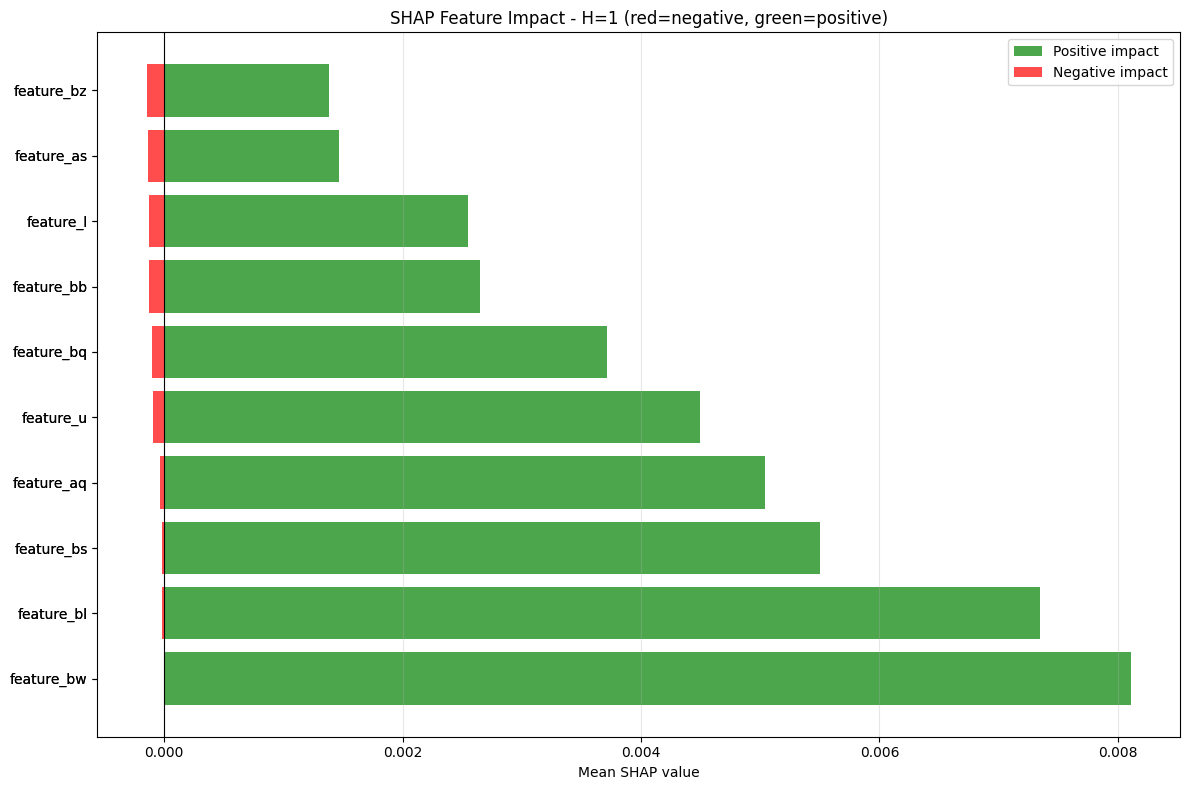

  Saved balanced SHAP plot for H=1


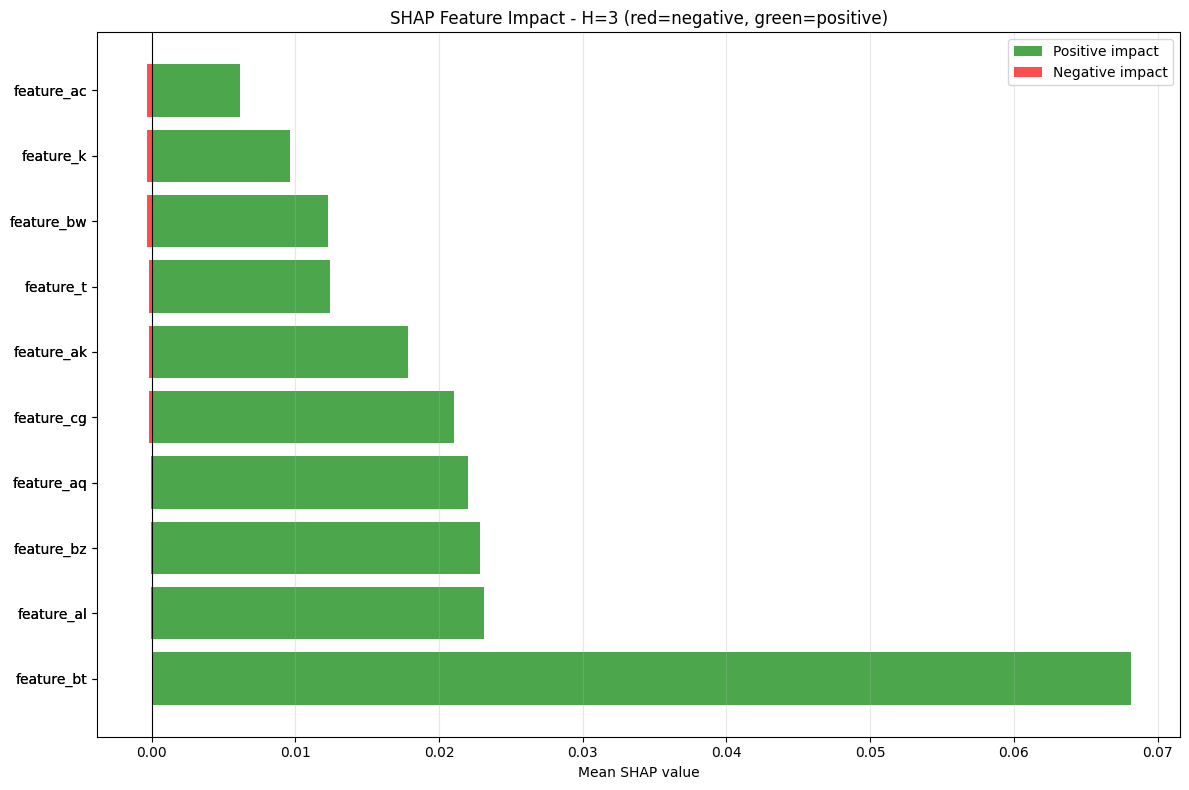

  Saved balanced SHAP plot for H=3


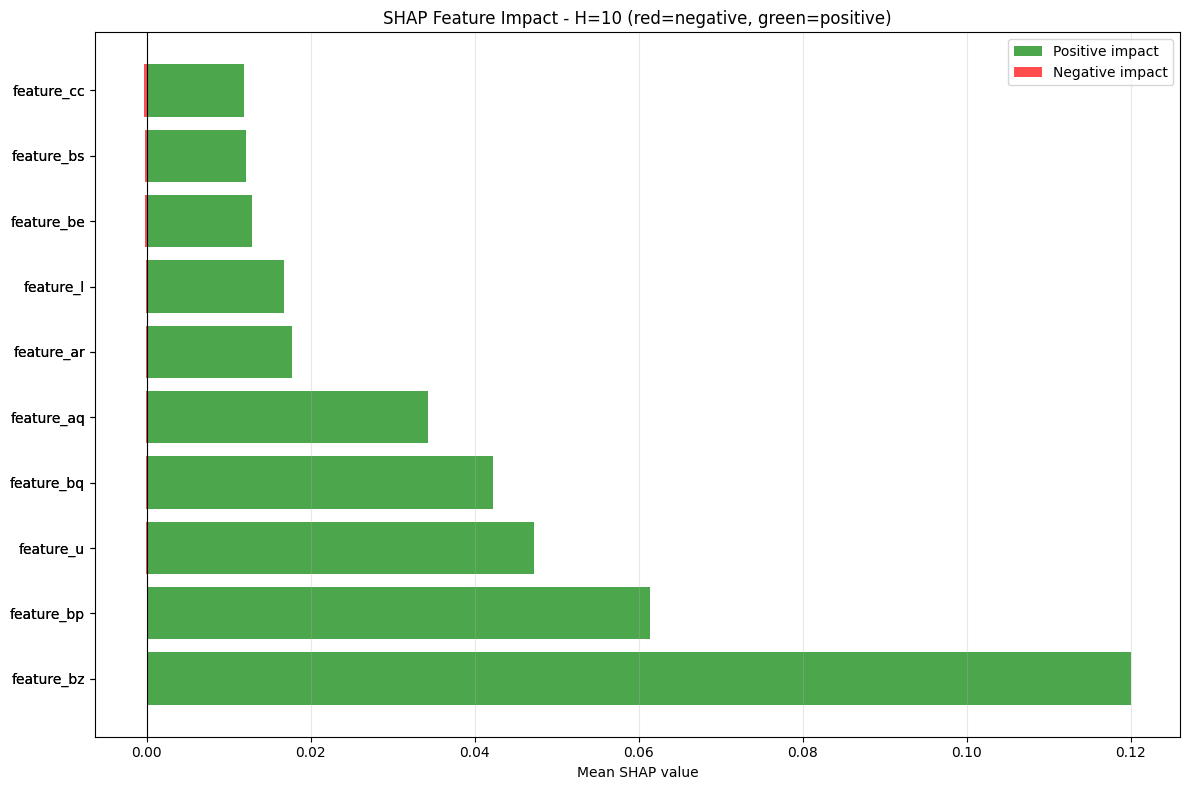

  Saved balanced SHAP plot for H=10


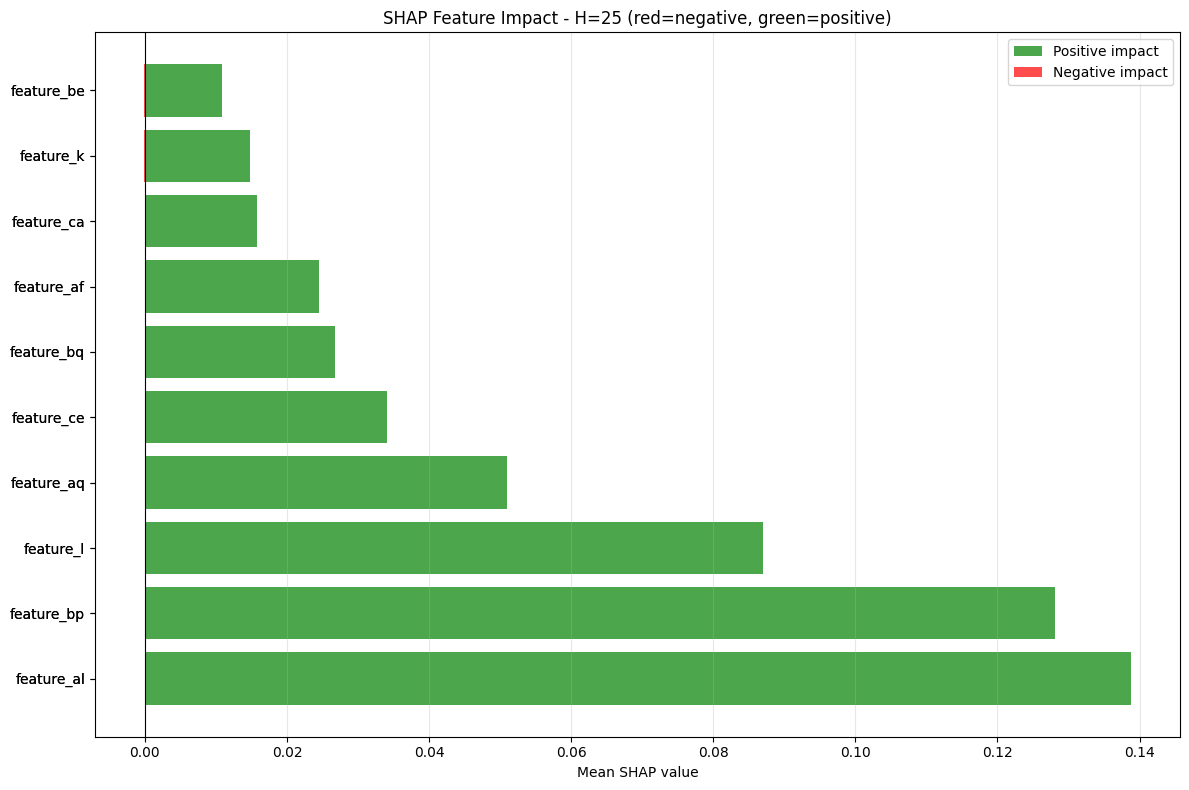

  Saved balanced SHAP plot for H=25


In [7]:
# ============================================
# SHAP BALANCED BARCHART (negative left, positive right)
# ============================================

import matplotlib.pyplot as plt
import numpy as np

for h in HORIZONS:
    mean_shap = shap_results[h]['mean_shap_dir']  # use direction (not absolute)
    features = shap_results[h]['features']
    
    # Get top 10 positive and top 10 negative (by absolute SHAP)
    pos_indices = np.where(mean_shap > 0)[0]
    neg_indices = np.where(mean_shap < 0)[0]
    
    pos_sorted = pos_indices[np.argsort(mean_shap[pos_indices])[::-1]][:10]
    neg_sorted = neg_indices[np.argsort(-mean_shap[neg_indices])[:10]]  # most negative first
    
    pos_features = [features[i] for i in pos_sorted]
    pos_values = [mean_shap[i] for i in pos_sorted]
    neg_features = [features[i] for i in neg_sorted]
    neg_values = [mean_shap[i] for i in neg_sorted]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Positive bars (right)
    y_pos = np.arange(len(pos_features))
    ax.barh(y_pos, pos_values, color='green', alpha=0.7, label='Positive impact')
    
    # Negative bars (left)
    y_neg = np.arange(len(neg_features))
    ax.barh(y_neg, neg_values, color='red', alpha=0.7, label='Negative impact')
    
    # Formatting
    ax.set_yticks(np.concatenate([y_neg, y_pos]))
    ax.set_yticklabels(neg_features + pos_features)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean SHAP value')
    ax.set_title(f'SHAP Feature Impact - H={h} (red=negative, green=positive)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/shap_balanced_h{h}.png', dpi=150)
    plt.show()
    #plt.close()
    print(f"  Saved balanced SHAP plot for H={h}")

In [8]:
# ============================================
# SECTION 4: FEATURE ENGINEERING (FINAL - NO CONCAT)
# ============================================
# Cel: Inżynieria na top SHAP features (rolling, delta, lag)
# UWAGA: Dane pozostają osobno per horyzont (różne cechy)
# ============================================

print("\n" + "="*60)
print("FEATURE ENGINEERING (based on SHAP)")
print("="*60)

# ============================================
# 1. ULTRA BALANCE
# ============================================
print("\n📌 Creating ultra_balance...")

train_full = train_full.with_columns(
    (pl.col('feature_bz') + pl.col('feature_cc') - 2.0 * pl.col('feature_aw')).alias('ultra_balance')
).fill_null(0)

test_full = test_full.with_columns(
    (pl.col('feature_bz') + pl.col('feature_cc') - 2.0 * pl.col('feature_aw')).alias('ultra_balance')
).fill_null(0)

print("  ✅ ultra_balance added")

# ============================================
# 2. TOP FEATURES PER HORIZON (z SHAP)
# ============================================
print("\n📌 Defining feature sets per horizon...")

time_features = ['time_mod_50', 'time_mod_200', 'sin_year', 'sin_month']

features_per_horizon = {
    1: {
        'positive': ['feature_bz', 'feature_al', 'feature_bw', 'feature_aq', 'feature_u'],
        'negative': ['feature_by', 'feature_bx', 'feature_cg', 'feature_cc', 'feature_cb']
    },
    3: {
        'positive': ['feature_bp', 'feature_cg', 'feature_al', 'feature_bt', 'feature_bz'],
        'negative': ['feature_by', 'feature_cc', 'feature_cd', 'feature_aj', 'feature_u']
    },
    10: {
        'positive': ['feature_u', 'feature_bz', 'feature_bp', 'feature_aq', 'feature_bx'],
        'negative': ['feature_by', 'feature_cg', 'feature_v', 'feature_al', 'feature_am']
    },
    25: {
        'positive': ['feature_bp', 'feature_al', 'feature_v', 'feature_bz', 'feature_l'],
        'negative': ['feature_cg', 'feature_by', 'feature_m', 'feature_am', 'feature_cb']
    }
}

# ============================================
# 3. INŻYNIERIA (rolling, delta, lag) - BEZ ŁĄCZENIA
# ============================================
print("\n📌 Applying engineering (rolling, delta, lag)...")

# Przechowujemy przetworzone dane w słownikach (nie łączymy!)
train_by_horizon = {}
test_by_horizon = {}
final_features_per_horizon = {}

for h in HORIZONS:
    print(f"\n  Processing H={h}...")
    
    train_h = train_full.filter(pl.col('horizon') == h)
    test_h = test_full.filter(pl.col('horizon') == h)
    
    # Wszystkie cechy dla tego horyzontu
    base_features = features_per_horizon[h]['positive'] + features_per_horizon[h]['negative']
    base_features = list(dict.fromkeys(base_features))
    
    for feat in base_features:
        if feat not in train_h.columns:
            continue
            
        # Rolling mean/std (windows 3,5)
        for w in [3, 5]:
            train_h = train_h.with_columns(
                pl.col(feat).rolling_mean(window_size=w, min_periods=1).over(['code', 'sub_code', 'sub_category', 'horizon']).alias(f'{feat}_roll_mean_{w}')
            ).fill_null(0)
            test_h = test_h.with_columns(
                pl.col(feat).rolling_mean(window_size=w, min_periods=1).over(['code', 'sub_code', 'sub_category', 'horizon']).alias(f'{feat}_roll_mean_{w}')
            ).fill_null(0)
            
            train_h = train_h.with_columns(
                pl.col(feat).rolling_std(window_size=w, min_periods=1).over(['code', 'sub_code', 'sub_category', 'horizon']).alias(f'{feat}_roll_std_{w}')
            ).fill_null(0)
            test_h = test_h.with_columns(
                pl.col(feat).rolling_std(window_size=w, min_periods=1).over(['code', 'sub_code', 'sub_category', 'horizon']).alias(f'{feat}_roll_std_{w}')
            ).fill_null(0)
        
        # Delta
        train_h = train_h.with_columns(
            (pl.col(feat) - pl.col(feat).shift(1).over(['code', 'sub_code', 'sub_category', 'horizon'])).alias(f'{feat}_delta')
        ).fill_null(0)
        test_h = test_h.with_columns(
            (pl.col(feat) - pl.col(feat).shift(1).over(['code', 'sub_code', 'sub_category', 'horizon'])).alias(f'{feat}_delta')
        ).fill_null(0)
        
        # Lags (1,2,3)
        for lag in [1, 2, 3]:
            train_h = train_h.with_columns(
                pl.col(feat).shift(lag).over(['code', 'sub_code', 'sub_category', 'horizon']).alias(f'{feat}_lag_{lag}')
            ).fill_null(0)
            test_h = test_h.with_columns(
                pl.col(feat).shift(lag).over(['code', 'sub_code', 'sub_category', 'horizon']).alias(f'{feat}_lag_{lag}')
            ).fill_null(0)
    
    # Zbierz wszystkie cechy dla tego horyzontu
    engineered = []
    for feat in base_features:
        engineered.extend([
            f'{feat}_roll_mean_3', f'{feat}_roll_mean_5',
            f'{feat}_roll_std_3', f'{feat}_roll_std_5',
            f'{feat}_delta',
            f'{feat}_lag_1', f'{feat}_lag_2', f'{feat}_lag_3'
        ])
    
    extra = ['ultra_balance'] + time_features
    
    all_final = base_features + engineered + extra
    all_final = [c for c in all_final if c in train_h.columns]
    all_final = list(dict.fromkeys(all_final))
    
    final_features_per_horizon[h] = all_final
    train_by_horizon[h] = train_h
    test_by_horizon[h] = test_h
    
    print(f"    Final features: {len(all_final)}")

print("\n✅ Feature engineering complete (data stored per horizon)")


FEATURE ENGINEERING (based on SHAP)

📌 Creating ultra_balance...
  ✅ ultra_balance added

📌 Defining feature sets per horizon...

📌 Applying engineering (rolling, delta, lag)...

  Processing H=1...
    Final features: 91

  Processing H=3...
    Final features: 91

  Processing H=10...
    Final features: 91

  Processing H=25...
    Final features: 91

✅ Feature engineering complete (data stored per horizon)


In [9]:
# ============================================
# SECTION 5: LGBM v2 (with engineered features from SHAP)
# ============================================
# Cel: Trenowanie LightGBM na cechach inżynieryjnych (rolling, delta, lag)
# Porównanie z baseline (sekcja 2)
# Walidacja czasowa: train (ts ≤ 3000), valid (3001–3600)
# UWAGA: Używa train_by_horizon i test_by_horizon z sekcji 4
# ============================================

print("\n" + "="*60)
print("LGBM v2 (ENGINEERED FEATURES)")
print("="*60)

# ============================================
# PARAMETRY (identyczne jak w baseline dla porównania)
# ============================================
def get_lgbm_v2_params(horizon: int, seed: int = 42) -> dict:
    """Same params as baseline for fair comparison"""
    return {
        'objective': 'regression',
        'metric': 'rmse',
        'num_leaves': 50,
        'learning_rate': 0.05,
        'n_estimators': 300,
        'max_depth': 10,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'random_state': seed,
        'verbose': -1
    }

# ============================================
# STORE RESULTS
# ============================================
lgbm_v2_results = {}

# ============================================
# PĘTLA PO HORYZONTACH
# ============================================
for horizon in HORIZONS:
    print(f"\n{'='*60}")
    print(f"HORIZON: {horizon}")
    print(f"{'='*60}")
    
    # Get data from SECTION 4 (already filtered by horizon)
    train_h = train_by_horizon[horizon]
    test_h = test_by_horizon[horizon]
    
    # Split czasowy (same as baseline: train ≤ 3000, valid 3001–3600)
    train_split = train_h.filter(pl.col('ts_index') <= TRAIN_SPLIT)
    valid_split = train_h.filter(
        (pl.col('ts_index') >= VALID_START) & (pl.col('ts_index') <= VALID_END)
    )
    
    print(f"  Train samples: {len(train_split):,} (ts ≤ {TRAIN_SPLIT})")
    print(f"  Valid samples: {len(valid_split):,} ({VALID_START}–{VALID_END})")
    
    # Get features for this horizon (from SECTION 4)
    features = final_features_per_horizon[horizon]
    print(f"  Features: {len(features)}")
    
    # Prepare data
    X_train = train_split.select(features).to_numpy()
    y_train = train_split['y_target'].to_numpy().ravel()
    w_train = train_split['weight'].to_numpy().ravel()
    
    X_valid = valid_split.select(features).to_numpy()
    y_valid = valid_split['y_target'].to_numpy().ravel()
    w_valid = valid_split['weight'].to_numpy().ravel()
    
    # Train model
    params = get_lgbm_v2_params(horizon, SEEDS[0])
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_valid_pred = model.predict(X_valid)
    
    # ============================================
    # TRAIN METRICS
    # ============================================
    train_rmse = rmse(y_train, y_train_pred)
    train_mae = mae(y_train, y_train_pred)
    train_r2 = r2(y_train, y_train_pred)
    train_pearson = pearson(y_train, y_train_pred)
    train_weighted = weighted_rmse_score(y_train, y_train_pred, w_train)
    
    # ============================================
    # VALIDATION METRICS
    # ============================================
    valid_rmse = rmse(y_valid, y_valid_pred)
    valid_mae = mae(y_valid, y_valid_pred)
    valid_r2 = r2(y_valid, y_valid_pred)
    valid_pearson = pearson(y_valid, y_valid_pred)
    valid_weighted = weighted_rmse_score(y_valid, y_valid_pred, w_valid)
    
    # ============================================
    # OVERFIT CHECK
    # ============================================
    overfit_rmse = valid_rmse - train_rmse
    overfit_pearson = train_pearson - valid_pearson
    overfit_r2 = train_r2 - valid_r2
    
    # ============================================
    # DIAGNOSTICS
    # ============================================
    print(f"\n  📊 TRAIN METRICS:")
    print(f"    RMSE: {train_rmse:.6f}")
    print(f"    MAE: {train_mae:.6f}")
    print(f"    R²: {train_r2:.6f}")
    print(f"    Pearson: {train_pearson:.6f}")
    print(f"    Weighted RMSE: {train_weighted:.6f}")
    print(f"    y_pred std: {y_train_pred.std():.4f} (target std: {y_train.std():.4f})")
    
    print(f"\n  📊 VALIDATION METRICS:")
    print(f"    RMSE: {valid_rmse:.6f}")
    print(f"    MAE: {valid_mae:.6f}")
    print(f"    R²: {valid_r2:.6f}")
    print(f"    Pearson: {valid_pearson:.6f}")
    print(f"    Weighted RMSE: {valid_weighted:.6f}")
    print(f"    y_pred std: {y_valid_pred.std():.4f} (target std: {y_valid.std():.4f})")
    
    print(f"\n  📊 OVERFIT CHECK:")
    print(f"    RMSE diff (valid - train): {overfit_rmse:.6f} {'⚠️ OVERFIT' if overfit_rmse > 0.5 else '✅ OK'}")
    print(f"    Pearson diff (train - valid): {overfit_pearson:.6f}")
    print(f"    R² diff (train - valid): {overfit_r2:.6f}")
    
    # Store results
    lgbm_v2_results[horizon] = {
        'train': {
            'rmse': train_rmse, 'mae': train_mae, 'r2': train_r2,
            'pearson': train_pearson, 'weighted_rmse': train_weighted,
            'pred_std': y_train_pred.std(), 'target_std': y_train.std()
        },
        'valid': {
            'rmse': valid_rmse, 'mae': valid_mae, 'r2': valid_r2,
            'pearson': valid_pearson, 'weighted_rmse': valid_weighted,
            'pred_std': y_valid_pred.std(), 'target_std': y_valid.std()
        },
        'overfit': {
            'rmse_diff': overfit_rmse,
            'pearson_diff': overfit_pearson,
            'r2_diff': overfit_r2
        },
        'features': features,
        'model': model
    }

# ============================================
# PORÓWNANIE Z BASELINE (SEKCJA 2)
# ============================================
print("\n" + "="*80)
print("COMPARISON: BASELINE vs LGBM v2 (engineered features)")
print("="*80)

print(f"\n{'Horizon':<8} {'Metric':<15} {'Baseline':<12} {'LGBM v2':<12} {'Change':<10}")
print("-" * 65)

for h in HORIZONS:
    baseline_valid = baseline_results[h]['valid']
    v2_valid = lgbm_v2_results[h]['valid']
    
    # Weighted RMSE (higher = better)
    wrmse_change = v2_valid['weighted_rmse'] - baseline_valid['weighted_rmse']
    wrmse_arrow = "✅" if wrmse_change > 0 else "❌"
    
    print(f"{h:<8} {'Weighted RMSE':<15} {baseline_valid['weighted_rmse']:<12.6f} {v2_valid['weighted_rmse']:<12.6f} {wrmse_arrow} {wrmse_change:+.6f}")
    
    # Pearson (higher = better)
    pearson_change = v2_valid['pearson'] - baseline_valid['pearson']
    pearson_arrow = "✅" if pearson_change > 0 else "❌"
    print(f"{h:<8} {'Pearson':<15} {baseline_valid['pearson']:<12.6f} {v2_valid['pearson']:<12.6f} {pearson_arrow} {pearson_change:+.6f}")
    
    # RMSE (lower = better)
    rmse_change = v2_valid['rmse'] - baseline_valid['rmse']
    rmse_arrow = "✅" if rmse_change < 0 else "❌"
    print(f"{h:<8} {'RMSE':<15} {baseline_valid['rmse']:<12.6f} {v2_valid['rmse']:<12.6f} {rmse_arrow} {rmse_change:+.6f}")

# ============================================
# SAVE RESULTS FOR LATER COMPARISON
# ============================================
import json
with open('/kaggle/working/lgbm_v2_results.json', 'w') as f:
    # Convert numpy values to float for JSON
    results_serializable = {}
    for h in HORIZONS:
        results_serializable[str(h)] = {
            'train': {k: float(v) for k, v in lgbm_v2_results[h]['train'].items()},
            'valid': {k: float(v) for k, v in lgbm_v2_results[h]['valid'].items()},
            'overfit': {k: float(v) for k, v in lgbm_v2_results[h]['overfit'].items()}
        }
    json.dump(results_serializable, f, indent=2)
print("\n✅ Results saved to /kaggle/working/lgbm_v2_results.json")

print("\n" + "="*80)
print("✅ LGBM v2 complete")
print("="*80)


LGBM v2 (ENGINEERED FEATURES)

HORIZON: 1
  Train samples: 1,128,631 (ts ≤ 3000)
  Valid samples: 265,537 (3001–3600)
  Features: 91

  📊 TRAIN METRICS:
    RMSE: 11.953335
    MAE: 2.064473
    R²: 0.008317
    Pearson: 0.139957
    Weighted RMSE: 0.299975
    y_pred std: 0.4062 (target std: 12.0034)

  📊 VALIDATION METRICS:
    RMSE: 10.305300
    MAE: 2.357991
    R²: 0.002082
    Pearson: 0.049816
    Weighted RMSE: 0.000000
    y_pred std: 0.3128 (target std: 10.3160)

  📊 OVERFIT CHECK:
    RMSE diff (valid - train): -1.648034 ✅ OK
    Pearson diff (train - valid): 0.090141
    R² diff (train - valid): 0.006235

HORIZON: 3
  Train samples: 1,121,771 (ts ≤ 3000)
  Valid samples: 263,560 (3001–3600)
  Features: 91

  📊 TRAIN METRICS:
    RMSE: 19.529359
    MAE: 3.622887
    R²: 0.026307
    Pearson: 0.210718
    Weighted RMSE: 0.294686
    y_pred std: 1.5085 (target std: 19.7914)

  📊 VALIDATION METRICS:
    RMSE: 17.412680
    MAE: 4.161374
    R²: 0.001289
    Pearson: 0.042163

In [10]:
# ============================================
# SECTION 5B: LGBM v2 SUBMISSION (full train → test)
# ============================================
# Cel: Wygenerowanie submission dla LGBM v2
# Trening: WSZYSTKIE dane treningowe (ts ≤ 3601) dla każdego horyzontu
# Cechy: te same co w sekcji 5 (final_features_per_horizon)
# Dodatkowo: porównanie z baseline (jeśli baseline_submission_preds istnieje)
# ============================================

print("\n" + "="*60)
print("LGBM v2 - SUBMISSION (full train → test)")
print("="*60)

lgbm_v2_submission_preds = {}
lgbm_v2_test_metrics = {}

for horizon in HORIZONS:
    print(f"\n{'='*60}")
    print(f"HORIZON: {horizon}")
    print(f"{'='*60}")
    
    # Get data from SECTION 4 (already filtered by horizon)
    train_h = train_by_horizon[horizon]
    test_h = test_by_horizon[horizon]
    
    # Use ALL training data (ts ≤ 3601)
    train_full_h = train_h.filter(pl.col('ts_index') <= MAX_TS_TRAIN)
    
    # Get features for this horizon
    features = final_features_per_horizon[horizon]
    
    X_train = train_full_h.select(features).to_numpy()
    y_train = train_full_h['y_target'].to_numpy().ravel()
    w_train = train_full_h['weight'].to_numpy().ravel()
    
    X_test = test_h.select(features).to_numpy()
    
    print(f"  Train samples: {len(train_full_h):,}")
    print(f"  Test samples: {len(test_h):,}")
    print(f"  Features: {len(features)}")
    
    # Train model (same params as v2)
    params = get_lgbm_v2_params(horizon, SEEDS[0])
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, sample_weight=w_train)
    
    # Predict on test
    preds = model.predict(X_test)
    lgbm_v2_submission_preds[horizon] = {
        'ids': test_h['id'].to_numpy().ravel(),
        'predictions': preds
    }
    
    # Store test metrics
    lgbm_v2_test_metrics[horizon] = {
        'mean': np.mean(preds),
        'std': np.std(preds),
        'min': np.min(preds),
        'max': np.max(preds),
        'n_samples': len(preds)
    }
    
    print(f"\n  📊 TEST PREDICTIONS:")
    print(f"    Samples: {len(preds):,}")
    print(f"    Mean: {np.mean(preds):.6f}")
    print(f"    Std: {np.std(preds):.6f}")
    print(f"    Range: [{np.min(preds):.4f}, {np.max(preds):.4f}]")

# ============================================
# GENERATE SUBMISSION
# ============================================
print("\n" + "="*60)
print("GENERATING LGBM v2 SUBMISSION")
print("="*60)

all_ids = []
all_preds = []

for horizon in HORIZONS:
    all_ids.extend(lgbm_v2_submission_preds[horizon]['ids'])
    all_preds.extend(lgbm_v2_submission_preds[horizon]['predictions'])

submission_df = pl.DataFrame({'id': all_ids, 'prediction': all_preds})

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
submission_filename = f"lgbm_v2_submission_{timestamp}.csv"
submission_path = Path("/kaggle/working") / submission_filename
submission_df.write_csv(submission_path)

print(f"✅ Submission saved: {submission_path}")
print(f"📊 Shape: {submission_df.shape}")
print(f"📊 Prediction range: [{np.min(all_preds):.4f}, {np.max(all_preds):.4f}]")

# ============================================
# PORÓWNANIE Z BASELINE SUBMISSION (SEKCJA 2B)
# ============================================
print("\n" + "="*80)
print("COMPARISON: BASELINE vs LGBM v2 (TEST PREDICTIONS)")
print("="*80)

# Sprawdź czy baseline_submission_preds istnieje (z sekcji 2B)
if 'baseline_submission_preds' in dir() or 'baseline_submission_preds' in globals():
    print(f"\n{'Horizon':<8} {'Metric':<15} {'Baseline':<15} {'LGBM v2':<15} {'Change':<10}")
    print("-" * 70)
    
    for h in HORIZONS:
        baseline = baseline_submission_preds[h]['predictions']
        v2 = lgbm_v2_submission_preds[h]['predictions']
        
        baseline_mean = np.mean(baseline)
        v2_mean = np.mean(v2)
        baseline_std = np.std(baseline)
        v2_std = np.std(v2)
        baseline_range = np.max(baseline) - np.min(baseline)
        v2_range = np.max(v2) - np.min(v2)
        
        print(f"{h:<8} {'Mean':<15} {baseline_mean:<15.6f} {v2_mean:<15.6f} {v2_mean - baseline_mean:+.6f}")
        print(f"{h:<8} {'Std':<15} {baseline_std:<15.6f} {v2_std:<15.6f} {v2_std - baseline_std:+.6f}")
        print(f"{h:<8} {'Range':<15} {baseline_range:<15.6f} {v2_range:<15.6f} {v2_range - baseline_range:+.6f}")
        print(f"{h:<8} {'Samples':<15} {len(baseline):<15,} {len(v2):<15,} {'-'}")
        print("-" * 70)
else:
    print("\n⚠️ Baseline submission predictions not found. Run SECTION 2B first.")
    print("   Comparison skipped.")

print("\n" + "="*80)
print("✅ LGBM v2 submission complete")
print("="*80)


LGBM v2 - SUBMISSION (full train → test)

HORIZON: 1
  Train samples: 1,394,653
  Test samples: 379,617
  Features: 91

  📊 TEST PREDICTIONS:
    Samples: 379,617
    Mean: -0.127021
    Std: 0.697322
    Range: [-28.9939, 5.6207]

HORIZON: 3
  Train samples: 1,385,816
  Test samples: 376,558
  Features: 91

  📊 TEST PREDICTIONS:
    Samples: 376,558
    Mean: -0.688109
    Std: 3.675140
    Range: [-61.7300, 12.4202]

HORIZON: 10
  Train samples: 1,337,236
  Test samples: 362,057
  Features: 91

  📊 TEST PREDICTIONS:
    Samples: 362,057
    Mean: -1.708493
    Std: 7.427790
    Range: [-98.7794, 32.2432]

HORIZON: 25
  Train samples: 1,219,709
  Test samples: 328,875
  Features: 91

  📊 TEST PREDICTIONS:
    Samples: 328,875
    Mean: -3.451490
    Std: 14.038467
    Range: [-172.2638, 36.3520]

GENERATING LGBM v2 SUBMISSION
✅ Submission saved: /kaggle/working/lgbm_v2_submission_20260416_132420.csv
📊 Shape: (1447107, 2)
📊 Prediction range: [-172.2638, 36.3520]

COMPARISON: BASELINE 

In [11]:
# ============================================
# SECTION 5: LGBM v3 (with target encoding + early stopping)
# ============================================
# Cel: LGBM na SHAP top features + target encoding + early stopping
# Walidacja czasowa: train (ts ≤ 3000), valid (3001–3600)
# ============================================

print("\n" + "="*60)
print("LGBM v3 (TARGET ENCODING + EARLY STOPPING)")
print("="*60)

# ============================================
# 1. DODAJEMY TARGET ENCODING (przed treningiem)
# ============================================
print("\n📌 Adding target encoding (sub_category_te, sub_code_te)...")

# Target encoding computed ONLY on training data (ts ≤ 3000) – no leakage
te_train = train_full.filter(pl.col('ts_index') <= TRAIN_SPLIT)

# Compute mean y_target per sub_category and sub_code
sub_category_means = te_train.group_by('sub_category').agg(
    pl.col('y_target').mean().alias('sub_category_te')
)
sub_code_means = te_train.group_by('sub_code').agg(
    pl.col('y_target').mean().alias('sub_code_te')
)

# Join to train (all data)
train_full = train_full.join(sub_category_means, on='sub_category', how='left')
train_full = train_full.join(sub_code_means, on='sub_code', how='left')

# Join to test
test_full = test_full.join(sub_category_means, on='sub_category', how='left')
test_full = test_full.join(sub_code_means, on='sub_code', how='left')

# Fill missing (groups not seen in training) with global mean
global_mean = te_train['y_target'].mean()
train_full = train_full.with_columns(
    pl.col('sub_category_te').fill_null(global_mean),
    pl.col('sub_code_te').fill_null(global_mean)
)
test_full = test_full.with_columns(
    pl.col('sub_category_te').fill_null(global_mean),
    pl.col('sub_code_te').fill_null(global_mean)
)

print("  ✅ Target encoding added (sub_category_te, sub_code_te)")

# ============================================
# 2. UPDATE FINAL FEATURES PER HORIZON (add target encoding)
# ============================================
print("\n📌 Updating feature sets with target encoding...")

for h in HORIZONS:
    # Add target encoding columns to existing features
    final_features_per_horizon[h] = final_features_per_horizon[h] + ['sub_category_te', 'sub_code_te']
    final_features_per_horizon[h] = list(dict.fromkeys(final_features_per_horizon[h]))
    print(f"  H={h}: {len(final_features_per_horizon[h])} features (including target encoding)")

# ============================================
# 3. PARAMETRY (z early stopping)
# ============================================
def get_lgbm_v3_params(horizon: int, seed: int = 42) -> dict:
    """Same params as baseline + early stopping"""
    return {
        'objective': 'regression',
        'metric': 'rmse',
        'num_leaves': 50,
        'learning_rate': 0.05,
        'n_estimators': 1000,  # increased for early stopping
        'max_depth': 10,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'random_state': seed,
        'verbose': -1
    }

# ============================================
# 4. STORE RESULTS
# ============================================
lgbm_v3_results = {}

# ============================================
# 5. PĘTLA PO HORYZONTACH (z early stopping)
# ============================================
for horizon in HORIZONS:
    print(f"\n{'='*60}")
    print(f"HORIZON: {horizon}")
    print(f"{'='*60}")
    
    # Get data from SECTION 4 (already filtered by horizon)
    train_h = train_by_horizon[horizon]
    test_h = test_by_horizon[horizon]
    
    # Add target encoding columns to train_h and test_h
    train_h = train_h.join(sub_category_means, on='sub_category', how='left')
    train_h = train_h.join(sub_code_means, on='sub_code', how='left')
    train_h = train_h.with_columns(
        pl.col('sub_category_te').fill_null(global_mean),
        pl.col('sub_code_te').fill_null(global_mean)
    )
    
    test_h = test_h.join(sub_category_means, on='sub_category', how='left')
    test_h = test_h.join(sub_code_means, on='sub_code', how='left')
    test_h = test_h.with_columns(
        pl.col('sub_category_te').fill_null(global_mean),
        pl.col('sub_code_te').fill_null(global_mean)
    )
    
    # Split czasowy
    train_split = train_h.filter(pl.col('ts_index') <= TRAIN_SPLIT)
    valid_split = train_h.filter(
        (pl.col('ts_index') >= VALID_START) & (pl.col('ts_index') <= VALID_END)
    )
    
    print(f"  Train samples: {len(train_split):,} (ts ≤ {TRAIN_SPLIT})")
    print(f"  Valid samples: {len(valid_split):,} ({VALID_START}–{VALID_END})")
    
    # Get features for this horizon (including target encoding)
    features = final_features_per_horizon[horizon]
    print(f"  Features: {len(features)}")
    
    # Prepare data
    X_train = train_split.select(features).to_numpy()
    y_train = train_split['y_target'].to_numpy().ravel()
    w_train = train_split['weight'].to_numpy().ravel()
    
    X_valid = valid_split.select(features).to_numpy()
    y_valid = valid_split['y_target'].to_numpy().ravel()
    w_valid = valid_split['weight'].to_numpy().ravel()
    
    # Train model with early stopping
    params = get_lgbm_v3_params(horizon, SEEDS[0])
    model = lgb.LGBMRegressor(**params)
    
    model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_valid, y_valid)],
        eval_sample_weight=[w_valid],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
    )
    
    best_iter = model.best_iteration_
    print(f"  Best iteration: {best_iter} (out of {params['n_estimators']})")
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_valid_pred = model.predict(X_valid)
    
    # ============================================
    # METRICS
    # ============================================
    train_weighted = weighted_rmse_score(y_train, y_train_pred, w_train)
    valid_weighted = weighted_rmse_score(y_valid, y_valid_pred, w_valid)
    train_pearson = pearson(y_train, y_train_pred)
    valid_pearson = pearson(y_valid, y_valid_pred)
    train_rmse = rmse(y_train, y_train_pred)
    valid_rmse = rmse(y_valid, y_valid_pred)
    
    print(f"\n  📊 TRAIN METRICS:")
    print(f"    Weighted RMSE: {train_weighted:.6f}")
    print(f"    Pearson: {train_pearson:.6f}")
    print(f"    RMSE: {train_rmse:.6f}")
    print(f"    y_pred std: {y_train_pred.std():.4f} (target std: {y_train.std():.4f})")
    
    print(f"\n  📊 VALIDATION METRICS:")
    print(f"    Weighted RMSE: {valid_weighted:.6f}")
    print(f"    Pearson: {valid_pearson:.6f}")
    print(f"    RMSE: {valid_rmse:.6f}")
    print(f"    y_pred std: {y_valid_pred.std():.4f} (target std: {y_valid.std():.4f})")
    
    # Store results
    lgbm_v3_results[horizon] = {
        'train': {
            'weighted_rmse': train_weighted,
            'pearson': train_pearson,
            'rmse': train_rmse,
            'pred_std': y_train_pred.std(),
            'target_std': y_train.std()
        },
        'valid': {
            'weighted_rmse': valid_weighted,
            'pearson': valid_pearson,
            'rmse': valid_rmse,
            'pred_std': y_valid_pred.std(),
            'target_std': y_valid.std()
        },
        'best_iteration': best_iter,
        'features': features,
        'model': model
    }

# ============================================
# 6. PODSUMOWANIE
# ============================================
print("\n" + "="*80)
print("LGBM v3 - SUMMARY")
print("="*80)

print(f"\n{'Horizon':<8} {'Train W.RMSE':<14} {'Valid W.RMSE':<14} {'Train Pearson':<14} {'Valid Pearson':<14} {'Best Iter':<10}")
print("-" * 80)

for h in HORIZONS:
    tr = lgbm_v3_results[h]['train']
    val = lgbm_v3_results[h]['valid']
    bi = lgbm_v3_results[h]['best_iteration']
    print(f"{h:<8} {tr['weighted_rmse']:<14.6f} {val['weighted_rmse']:<14.6f} {tr['pearson']:<14.6f} {val['pearson']:<14.6f} {bi:<10}")

print("\n" + "="*80)
print("✅ LGBM v3 complete (target encoding + early stopping)")
print("="*80)


LGBM v3 (TARGET ENCODING + EARLY STOPPING)

📌 Adding target encoding (sub_category_te, sub_code_te)...
  ✅ Target encoding added (sub_category_te, sub_code_te)

📌 Updating feature sets with target encoding...
  H=1: 93 features (including target encoding)
  H=3: 93 features (including target encoding)
  H=10: 93 features (including target encoding)
  H=25: 93 features (including target encoding)

HORIZON: 1
  Train samples: 1,128,631 (ts ≤ 3000)
  Valid samples: 265,537 (3001–3600)
  Features: 93
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[18]	valid_0's rmse: 0.00118405
  Best iteration: 18 (out of 1000)

  📊 TRAIN METRICS:
    Weighted RMSE: 0.115578
    Pearson: 0.082953
    RMSE: 11.991647
    y_pred std: 0.1557 (target std: 12.0034)

  📊 VALIDATION METRICS:
    Weighted RMSE: 0.034621
    Pearson: 0.044520
    RMSE: 10.311035
    y_pred std: 0.1314 (target std: 10.3160)

HORIZON: 3
  Train samples: 1,121,771 (ts ≤ 3000)
  Valid 

In [12]:
# ============================================
# SECTION 5B: LGBM v3 SUBMISSION (full train → test)
# ============================================
# Cel: Wygenerowanie submission dla LGBM v3
# Trening: WSZYSTKIE dane treningowe (ts ≤ 3601) dla każdego horyzontu
# Cechy: SHAP top features + target encoding + time features
# Early stopping: TAK (na walidacji czasowej)
# ============================================

print("\n" + "="*60)
print("LGBM v3 - SUBMISSION (full train → test)")
print("="*60)

lgbm_v3_submission_preds = {}
lgbm_v3_test_metrics = {}

# Target encoding mapping (from previous cell – already computed)
# sub_category_means, sub_code_means, global_mean exist from SECTION 5

for horizon in HORIZONS:
    print(f"\n{'='*60}")
    print(f"HORIZON: {horizon}")
    print(f"{'='*60}")
    
    # Get data from SECTION 4
    train_h = train_by_horizon[horizon]
    test_h = test_by_horizon[horizon]
    
    # Add target encoding columns
    train_h = train_h.join(sub_category_means, on='sub_category', how='left')
    train_h = train_h.join(sub_code_means, on='sub_code', how='left')
    train_h = train_h.with_columns(
        pl.col('sub_category_te').fill_null(global_mean),
        pl.col('sub_code_te').fill_null(global_mean)
    )
    
    test_h = test_h.join(sub_category_means, on='sub_category', how='left')
    test_h = test_h.join(sub_code_means, on='sub_code', how='left')
    test_h = test_h.with_columns(
        pl.col('sub_category_te').fill_null(global_mean),
        pl.col('sub_code_te').fill_null(global_mean)
    )
    
    # Use ALL training data (ts ≤ 3601)
    train_full_h = train_h.filter(pl.col('ts_index') <= MAX_TS_TRAIN)
    
    # Split for early stopping (train/valid within full data)
    train_split = train_full_h.filter(pl.col('ts_index') <= TRAIN_SPLIT)
    valid_split = train_full_h.filter(
        (pl.col('ts_index') >= VALID_START) & (pl.col('ts_index') <= VALID_END)
    )
    
    # Get features for this horizon
    features = final_features_per_horizon[horizon]
    
    X_train = train_split.select(features).to_numpy()
    y_train = train_split['y_target'].to_numpy().ravel()
    w_train = train_split['weight'].to_numpy().ravel()
    
    X_valid = valid_split.select(features).to_numpy()
    y_valid = valid_split['y_target'].to_numpy().ravel()
    w_valid = valid_split['weight'].to_numpy().ravel()
    
    X_test = test_h.select(features).to_numpy()
    
    print(f"  Train samples: {len(train_split):,} (ts ≤ {TRAIN_SPLIT})")
    print(f"  Valid samples: {len(valid_split):,} ({VALID_START}–{VALID_END})")
    print(f"  Test samples: {len(test_h):,}")
    print(f"  Features: {len(features)}")
    
    # Train model with early stopping
    params = get_lgbm_v3_params(horizon, SEEDS[0])
    model = lgb.LGBMRegressor(**params)
    
    model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_valid, y_valid)],
        eval_sample_weight=[w_valid],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
    )
    
    best_iter = model.best_iteration_
    print(f"  Best iteration: {best_iter}")
    
    # Predict on test
    preds = model.predict(X_test)
    lgbm_v3_submission_preds[horizon] = {
        'ids': test_h['id'].to_numpy().ravel(),
        'predictions': preds
    }
    
    lgbm_v3_test_metrics[horizon] = {
        'mean': np.mean(preds),
        'std': np.std(preds),
        'min': np.min(preds),
        'max': np.max(preds),
        'n_samples': len(preds),
        'best_iteration': best_iter
    }
    
    print(f"\n  📊 TEST PREDICTIONS:")
    print(f"    Samples: {len(preds):,}")
    print(f"    Mean: {np.mean(preds):.6f}")
    print(f"    Std: {np.std(preds):.6f}")
    print(f"    Range: [{np.min(preds):.4f}, {np.max(preds):.4f}]")

# ============================================
# GENERATE SUBMISSION
# ============================================
print("\n" + "="*60)
print("GENERATING LGBM v3 SUBMISSION")
print("="*60)

all_ids = []
all_preds = []

for horizon in HORIZONS:
    all_ids.extend(lgbm_v3_submission_preds[horizon]['ids'])
    all_preds.extend(lgbm_v3_submission_preds[horizon]['predictions'])

submission_df = pl.DataFrame({'id': all_ids, 'prediction': all_preds})

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
submission_filename = f"lgbm_v3_submission_{timestamp}.csv"
submission_path = Path("/kaggle/working") / submission_filename
submission_df.write_csv(submission_path)

print(f"✅ Submission saved: {submission_path}")
print(f"📊 Shape: {submission_df.shape}")
print(f"📊 Prediction range: [{np.min(all_preds):.4f}, {np.max(all_preds):.4f}]")

# ============================================
# PORÓWNANIE Z LGBM v2
# ============================================
print("\n" + "="*80)
print("COMPARISON: LGBM v2 vs LGBM v3 (TEST PREDICTIONS)")
print("="*80)

# Check if v2 results exist
v2_exists = 'lgbm_v2_submission_preds' in globals()

if v2_exists:
    print(f"\n{'Horizon':<8} {'Metric':<15} {'LGBM v2':<15} {'LGBM v3':<15} {'Change':<10}")
    print("-" * 70)
    
    for h in HORIZONS:
        v2 = lgbm_v2_submission_preds[h]['predictions']
        v3 = lgbm_v3_submission_preds[h]['predictions']
        
        v2_mean = np.mean(v2)
        v3_mean = np.mean(v3)
        v2_std = np.std(v2)
        v3_std = np.std(v3)
        v2_range = np.max(v2) - np.min(v2)
        v3_range = np.max(v3) - np.min(v3)
        
        print(f"{h:<8} {'Mean':<15} {v2_mean:<15.6f} {v3_mean:<15.6f} {v3_mean - v2_mean:+.6f}")
        print(f"{h:<8} {'Std':<15} {v2_std:<15.6f} {v3_std:<15.6f} {v3_std - v2_std:+.6f}")
        print(f"{h:<8} {'Range':<15} {v2_range:<15.6f} {v3_range:<15.6f} {v3_range - v2_range:+.6f}")
        print(f"{h:<8} {'Best Iter':<15} {'-':<15} {lgbm_v3_test_metrics[h]['best_iteration']:<15} {'-'}")
        print("-" * 70)
else:
    print("\n⚠️ LGBM v2 submission not found. Run SECTION 5B first.")
    print("   Comparison skipped.")

print("\n" + "="*80)
print("✅ LGBM v3 submission complete")
print("="*80)


LGBM v3 - SUBMISSION (full train → test)

HORIZON: 1
  Train samples: 1,128,631 (ts ≤ 3000)
  Valid samples: 265,537 (3001–3600)
  Test samples: 379,617
  Features: 93
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[18]	valid_0's rmse: 0.00118405
  Best iteration: 18

  📊 TEST PREDICTIONS:
    Samples: 379,617
    Mean: -0.046603
    Std: 0.238626
    Range: [-4.5790, 2.0079]

HORIZON: 3
  Train samples: 1,121,771 (ts ≤ 3000)
  Valid samples: 263,560 (3001–3600)
  Test samples: 376,558
  Features: 93
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[51]	valid_0's rmse: 0.0020109
  Best iteration: 51

  📊 TEST PREDICTIONS:
    Samples: 376,558
    Mean: -0.453350
    Std: 2.306533
    Range: [-49.7592, 8.5803]

HORIZON: 10
  Train samples: 1,083,610 (ts ≤ 3000)
  Valid samples: 253,146 (3001–3600)
  Test samples: 362,057
  Features: 93
Training until validation scores don't improve for 50 ro

In [13]:
# ============================================
# SECTION 5C: LGBM v3 (NO ULTRA_BALANCE)
# ============================================
# Cel: LGBM v3 z target encoding + early stopping, ale BEZ ultra_balance
# Sprawdzenie czy ultra_balance dodaje sygnał czy szum
# ============================================

print("\n" + "="*60)
print("LGBM v3 (NO ULTRA_BALANCE)")
print("="*60)

# ============================================
# 1. KOPIUJEMY FEATURES PER HORIZON (USUWAMY ultra_balance)
# ============================================
print("\n📌 Removing ultra_balance from feature sets...")

final_features_no_ultra = {}

for h in HORIZONS:
    # Kopiuj istniejące features
    features = final_features_per_horizon[h].copy()
    # Usuń ultra_balance jeśli istnieje
    if 'ultra_balance' in features:
        features.remove('ultra_balance')
    final_features_no_ultra[h] = features
    print(f"  H={h}: {len(features)} features (ultra_balance removed)")

# ============================================
# 2. TARGET ENCODING (już istnieje z v3)
# ============================================

# ============================================
# 3. PARAMETRY (bez zmian)
# ============================================
def get_lgbm_v3_params(horizon: int, seed: int = 42) -> dict:
    return {
        'objective': 'regression',
        'metric': 'rmse',
        'num_leaves': 50,
        'learning_rate': 0.05,
        'n_estimators': 1000,
        'max_depth': 10,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 0.1,
        'random_state': seed,
        'verbose': -1
    }

# ============================================
# 4. SUBMISSION (full train → test)
# ============================================
print("\n" + "="*60)
print("LGBM v3 (NO ULTRA) - SUBMISSION")
print("="*60)

lgbm_v3_no_ultra_preds = {}

for horizon in HORIZONS:
    print(f"\n{'='*60}")
    print(f"HORIZON: {horizon}")
    print(f"{'='*60}")
    
    # Get data from SECTION 4
    train_h = train_by_horizon[horizon]
    test_h = test_by_horizon[horizon]
    
    # Add target encoding columns
    train_h = train_h.join(sub_category_means, on='sub_category', how='left')
    train_h = train_h.join(sub_code_means, on='sub_code', how='left')
    train_h = train_h.with_columns(
        pl.col('sub_category_te').fill_null(global_mean),
        pl.col('sub_code_te').fill_null(global_mean)
    )
    
    test_h = test_h.join(sub_category_means, on='sub_category', how='left')
    test_h = test_h.join(sub_code_means, on='sub_code', how='left')
    test_h = test_h.with_columns(
        pl.col('sub_category_te').fill_null(global_mean),
        pl.col('sub_code_te').fill_null(global_mean)
    )
    
    # Use ALL training data
    train_full_h = train_h.filter(pl.col('ts_index') <= MAX_TS_TRAIN)
    
    # Split for early stopping
    train_split = train_full_h.filter(pl.col('ts_index') <= TRAIN_SPLIT)
    valid_split = train_full_h.filter(
        (pl.col('ts_index') >= VALID_START) & (pl.col('ts_index') <= VALID_END)
    )
    
    # Get features (without ultra_balance)
    features = final_features_no_ultra[horizon]
    
    X_train = train_split.select(features).to_numpy()
    y_train = train_split['y_target'].to_numpy().ravel()
    w_train = train_split['weight'].to_numpy().ravel()
    
    X_valid = valid_split.select(features).to_numpy()
    y_valid = valid_split['y_target'].to_numpy().ravel()
    w_valid = valid_split['weight'].to_numpy().ravel()
    
    X_test = test_h.select(features).to_numpy()
    
    print(f"  Train samples: {len(train_split):,}")
    print(f"  Valid samples: {len(valid_split):,}")
    print(f"  Test samples: {len(test_h):,}")
    print(f"  Features: {len(features)}")
    
    # Train model
    params = get_lgbm_v3_params(horizon, SEEDS[0])
    model = lgb.LGBMRegressor(**params)
    
    model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_valid, y_valid)],
        eval_sample_weight=[w_valid],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
    )
    
    best_iter = model.best_iteration_
    print(f"  Best iteration: {best_iter}")
    
    # Predict on test
    preds = model.predict(X_test)
    lgbm_v3_no_ultra_preds[horizon] = {
        'ids': test_h['id'].to_numpy().ravel(),
        'predictions': preds
    }
    
    print(f"\n  📊 TEST PREDICTIONS:")
    print(f"    Samples: {len(preds):,}")
    print(f"    Mean: {np.mean(preds):.6f}")
    print(f"    Std: {np.std(preds):.6f}")
    print(f"    Range: [{np.min(preds):.4f}, {np.max(preds):.4f}]")

# ============================================
# 5. GENERATE SUBMISSION
# ============================================
print("\n" + "="*60)
print("GENERATING SUBMISSION (NO ULTRA)")
print("="*60)

all_ids = []
all_preds = []

for horizon in HORIZONS:
    all_ids.extend(lgbm_v3_no_ultra_preds[horizon]['ids'])
    all_preds.extend(lgbm_v3_no_ultra_preds[horizon]['predictions'])

submission_df = pl.DataFrame({'id': all_ids, 'prediction': all_preds})

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
submission_filename = f"lgbm_v3_no_ultra_{timestamp}.csv"
submission_path = Path("/kaggle/working") / submission_filename
submission_df.write_csv(submission_path)

print(f"✅ Submission saved: {submission_path}")
print(f"📊 Shape: {submission_df.shape}")
print(f"📊 Prediction range: [{np.min(all_preds):.4f}, {np.max(all_preds):.4f}]")

# ============================================
# 6. PORÓWNANIE Z LGBM v3 (Z ULTRA)
# ============================================
print("\n" + "="*80)
print("COMPARISON: LGBM v3 (with ultra) vs LGBM v3 (no ultra)")
print("="*80)

# Check if v3 with ultra exists
v3_ultra_exists = 'lgbm_v3_submission_preds' in globals()

if v3_ultra_exists:
    print(f"\n{'Horizon':<8} {'Metric':<15} {'With Ultra':<15} {'Without Ultra':<15} {'Change':<10}")
    print("-" * 70)
    
    for h in HORIZONS:
        ultra = lgbm_v3_submission_preds[h]['predictions']
        no_ultra = lgbm_v3_no_ultra_preds[h]['predictions']
        
        ultra_mean = np.mean(ultra)
        no_ultra_mean = np.mean(no_ultra)
        ultra_std = np.std(ultra)
        no_ultra_std = np.std(no_ultra)
        ultra_range = np.max(ultra) - np.min(ultra)
        no_ultra_range = np.max(no_ultra) - np.min(no_ultra)
        
        print(f"{h:<8} {'Mean':<15} {ultra_mean:<15.6f} {no_ultra_mean:<15.6f} {no_ultra_mean - ultra_mean:+.6f}")
        print(f"{h:<8} {'Std':<15} {ultra_std:<15.6f} {no_ultra_std:<15.6f} {no_ultra_std - ultra_std:+.6f}")
        print(f"{h:<8} {'Range':<15} {ultra_range:<15.6f} {no_ultra_range:<15.6f} {no_ultra_range - ultra_range:+.6f}")
        print("-" * 70)
else:
    print("\n⚠️ LGBM v3 (with ultra) not found. Run SECTION 5B first.")
    print("   Comparison skipped.")

print("\n" + "="*80)
print("✅ LGBM v3 (no ultra) complete")
print("="*80)


LGBM v3 (NO ULTRA_BALANCE)

📌 Removing ultra_balance from feature sets...
  H=1: 92 features (ultra_balance removed)
  H=3: 92 features (ultra_balance removed)
  H=10: 92 features (ultra_balance removed)
  H=25: 92 features (ultra_balance removed)

LGBM v3 (NO ULTRA) - SUBMISSION

HORIZON: 1
  Train samples: 1,128,631
  Valid samples: 265,537
  Test samples: 379,617
  Features: 92
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[5]	valid_0's rmse: 0.0011842
  Best iteration: 5

  📊 TEST PREDICTIONS:
    Samples: 379,617
    Mean: -0.014388
    Std: 0.091315
    Range: [-2.6447, 1.7583]

HORIZON: 3
  Train samples: 1,121,771
  Valid samples: 263,560
  Test samples: 376,558
  Features: 92
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[41]	valid_0's rmse: 0.00200941
  Best iteration: 41

  📊 TEST PREDICTIONS:
    Samples: 376,558
    Mean: -0.397817
    Std: 2.110207
    Range: [-40.4976, 6.